In [1]:
import pandas as pd
import pyreadr
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind, mannwhitneyu
from statsmodels.stats.multitest import multipletests
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, auc, confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.pipeline import make_pipeline
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
sns.set_theme()

# EDA

In [2]:
data = pyreadr.read_r('data/prostate.rda')
xs = data[list(data.keys())[0]]
ys = data[list(data.keys())[1]]['prostate.y']
xs_cancer = xs[ys.astype(bool)]
xs_nocancer = xs[~ys.astype(bool)]

In [ ]:
corr = np.abs(np.corrcoef(xs, rowvar=False))
corr_df = pd.DataFrame(corr, index=xs.columns, columns=xs.columns)
threshold = 0.05
mask = (corr_df < threshold)
corr_pairs = corr_df.unstack()
corr_pairs = corr_pairs[corr_pairs.index.get_level_values(0) != corr_pairs.index.get_level_values(1)]
high_pairs = corr_pairs[corr_pairs < 0.05]
high_pairs = high_pairs.to_dict()
rel = corr_df[corr_df.mean()<0.1].index.tolist()
xs[rel]

In [8]:
missing_values_xs = xs.isnull().sum()
missing_values_ys = ys.isnull().sum()
print(missing_values_xs.sum())
print(missing_values_ys)

0
0


Outliers per gene (using IQR):


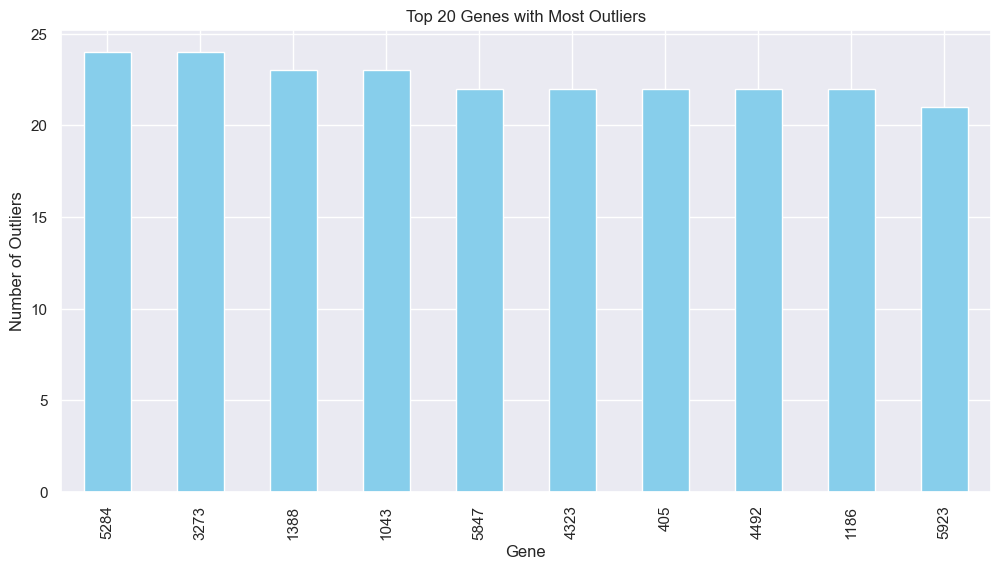

In [56]:
Q1 = xs.quantile(0.25)
Q3 = xs.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers_iqr = (xs < lower_bound) | (xs > upper_bound)

outliers_count = outliers_iqr.sum()
print("Outliers per gene (using IQR):")
sorted_outliers_count=outliers_count.sort_values(ascending=False)
top_10_outliers = sorted_outliers_count.head(10)
top_10_outliers.plot(kind='bar', figsize=(12, 6), color='skyblue')
plt.title('Top 20 Genes with Most Outliers')
plt.xlabel('Gene')
plt.ylabel('Number of Outliers')
plt.show()

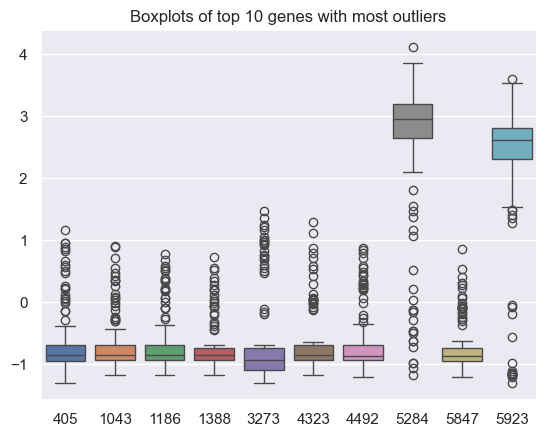

In [60]:
top10outliers_indices = sorted_outliers_count.head(10).index
sns.boxplot(xs[top10outliers_indices])
plt.title('Boxplots of top 10 genes with most outliers')
plt.show()

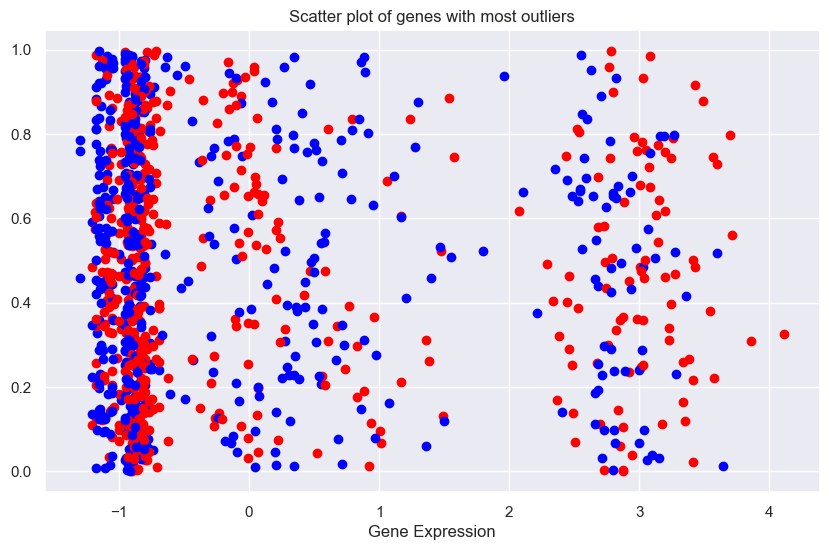

In [65]:
plt.figure(figsize=(10, 6))
for gene in top10outliers_indices:
    y_cancer = np.random.uniform(size=xs_cancer[gene].shape)
    y_nocancer = np.random.uniform(size=xs_nocancer[gene].shape)
    plt.scatter(xs_cancer[gene], y_cancer, color='red', label='Cancer')
    plt.scatter(xs_nocancer[gene], y_nocancer, color='blue', label='No Cancer')
plt.title(f'Scatter plot of genes with most outliers')
plt.xlabel('Gene Expression')
plt.show()

Text(0.5, 1.0, 'Density Plot of Gene Expression Means')

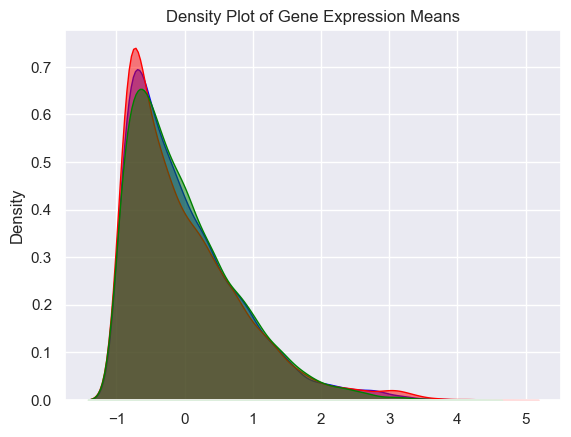

In [42]:
sns.kdeplot(xs.mean(), fill=True, color='blue', alpha=0.5)
sns.kdeplot(xs_cancer.mean(), fill=True, color='red', alpha=0.5)
sns.kdeplot(xs_nocancer.mean(), fill=True, color='green', alpha=0.5)
plt.title('Density Plot of Gene Expression Means')

Text(0.5, 1.0, 'Density Plot of Gene Expression Standard Deviations')

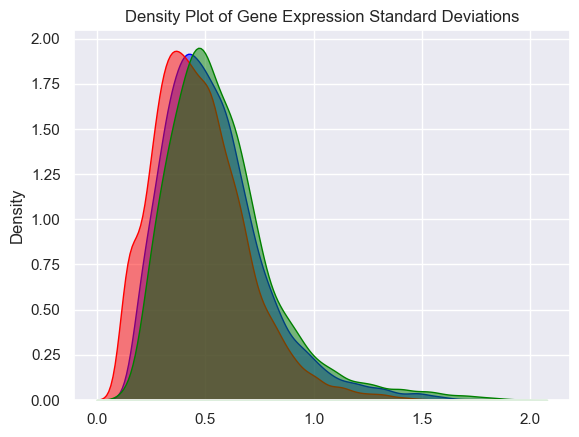

In [43]:
sns.kdeplot(xs.std(), fill=True, color='blue', alpha=0.5)
sns.kdeplot(xs_cancer.std(), fill=True, color='red', alpha=0.5)
sns.kdeplot(xs_nocancer.std(), fill=True, color='green', alpha=0.5)
plt.title('Density Plot of Gene Expression Standard Deviations')

Text(0.5, 1.0, 'Density Plot of Gene Expression Minimums')

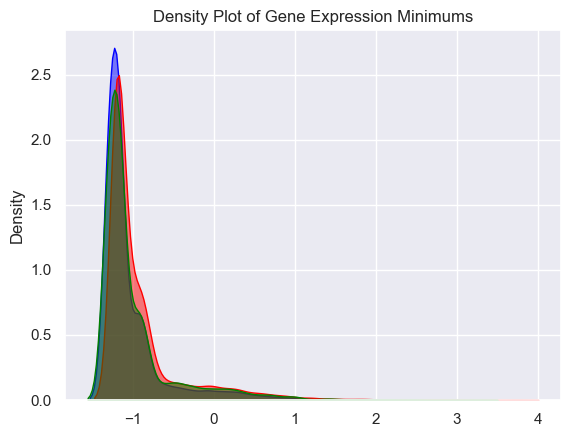

In [44]:
sns.kdeplot(xs.min(), fill=True, color='blue', alpha=0.5)
sns.kdeplot(xs_cancer.min(), fill=True, color='red', alpha=0.5)
sns.kdeplot(xs_nocancer.min(), fill=True, color='green', alpha=0.5)
plt.title('Density Plot of Gene Expression Minimums')

Text(0.5, 1.0, 'Density Plot of Gene Expression Maximums')

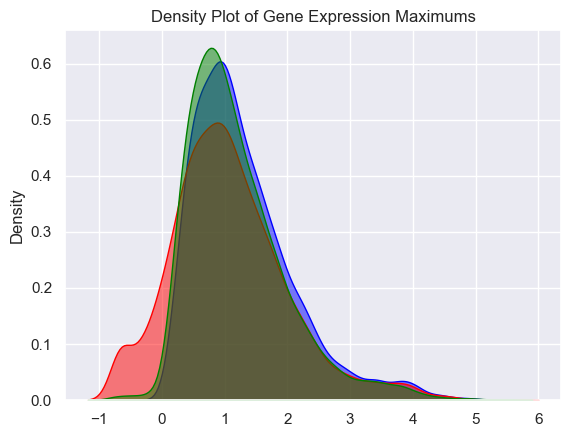

In [45]:
sns.kdeplot(xs.max(), fill=True, color='blue', alpha=0.5)
sns.kdeplot(xs_cancer.max(), fill=True, color='red', alpha=0.5)
sns.kdeplot(xs_nocancer.max(), fill=True, color='green', alpha=0.5)
plt.title('Density Plot of Gene Expression Maximums')

Text(0.5, 1.0, 'Density Plot of Gene Expression Medians')

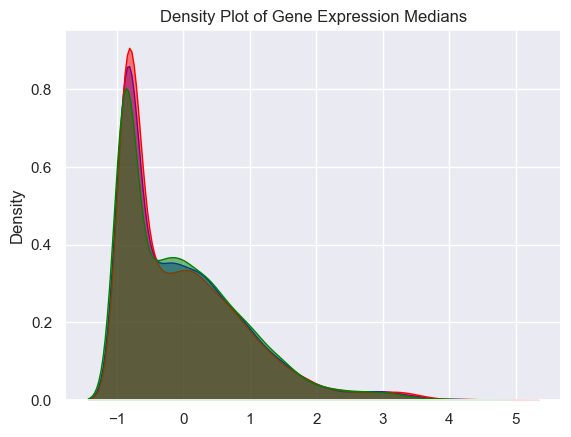

In [46]:
sns.kdeplot(xs.median(), fill=True, color='blue', alpha=0.5)
sns.kdeplot(xs_cancer.median(), fill=True, color='red', alpha=0.5)
sns.kdeplot(xs_nocancer.median(), fill=True, color='green', alpha=0.5)
plt.title('Density Plot of Gene Expression Medians')

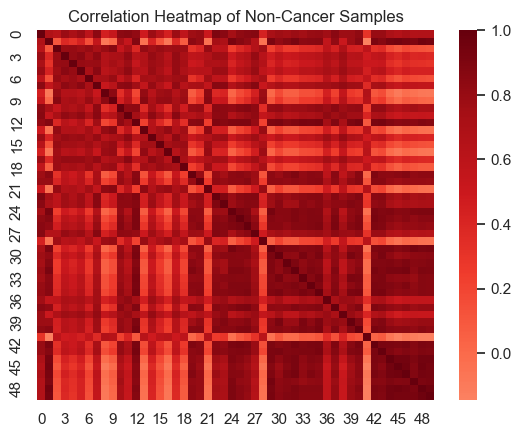

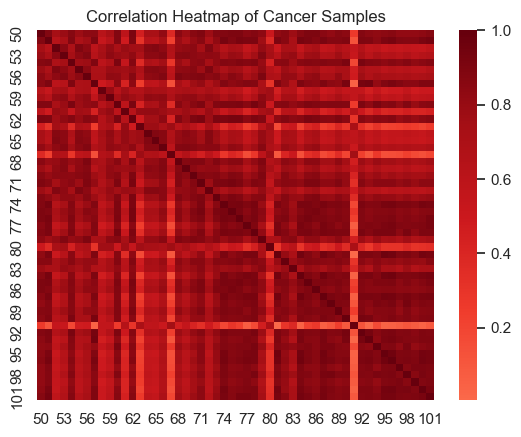

In [55]:
sns.heatmap(xs_nocancer.T.corr(), cmap='Reds', annot=False, center=0, cbar=True)
plt.title('Correlation Heatmap of Non-Cancer Samples')
plt.show()
sns.heatmap(xs_cancer.T.corr(), cmap='Reds', annot=False, center=0, cbar=True)
plt.title('Correlation Heatmap of Cancer Samples')
plt.show()


# Classification

## Models

In [5]:
LDA = LinearDiscriminantAnalysis()
QDA = QuadraticDiscriminantAnalysis()
kNN = KNeighborsClassifier(n_neighbors=5)
LR = LogisticRegression()
SVM = SVC(kernel='rbf', C=1, probability=True)

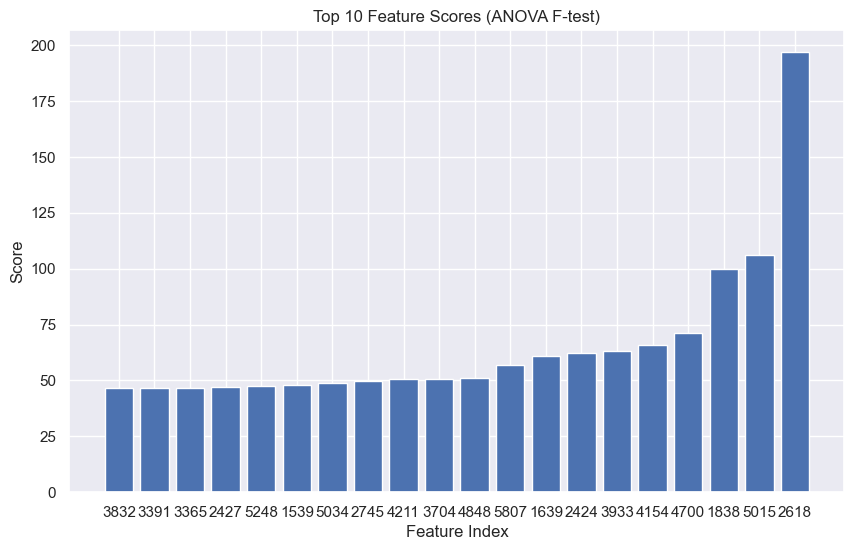

In [14]:
data = pyreadr.read_r('data/prostate.rda')
xs = data[list(data.keys())[0]]
ys = data[list(data.keys())[1]]['prostate.y']
selector = SelectKBest(f_classif, k=20)
selector.fit(xs, ys)
scores = selector.scores_
top_indices = np.argsort(scores)[-20:]
plt.figure(figsize=(10, 6))
plt.bar(range(20), scores[top_indices], tick_label=top_indices)
plt.title("Top 10 Feature Scores (ANOVA F-test)")
plt.xlabel("Feature Index")
plt.ylabel("Score")
plt.grid(True)
plt.show()

## T-test

In [8]:
X_train, X_test, y_train, y_test = train_test_split(xs, ys, test_size=0.2, stratify=ys)

X_train_c = X_train[y_train.astype(bool)]
X_train_nc = X_train[~y_train.astype(bool)]

p_values = [ttest_ind(X_train_nc[col], X_train_c[col], alternative='two-sided').pvalue for col in xs.columns]
reject, pvals_corrected, _, _ = multipletests(p_values, method='bonferroni')
selected_genes = xs.columns[pd.Series(pvals_corrected) < 0.05]
X_train_ttest = X_train[selected_genes]
X_test_ttest = X_test[selected_genes]

### LDA

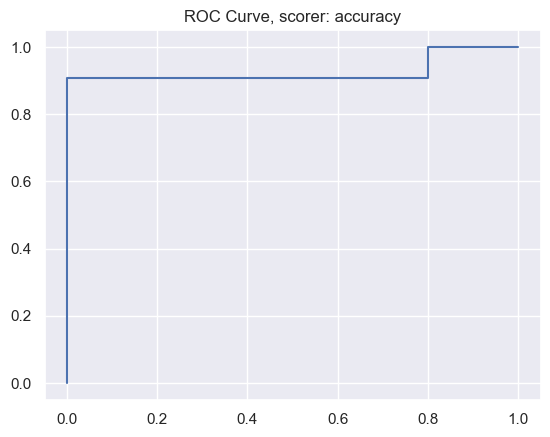

Scorer: accuracy
Accuracy: 0.8095238095238095
F1-score: 0.8333333333333334
ROC AUC: 0.9272727272727272
              precision    recall  f1-score   support

         0.0       0.88      0.70      0.78        10
         1.0       0.77      0.91      0.83        11

    accuracy                           0.81        21
   macro avg       0.82      0.80      0.81        21
weighted avg       0.82      0.81      0.81        21



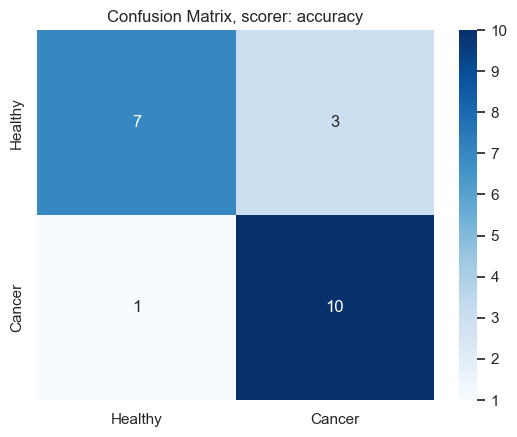

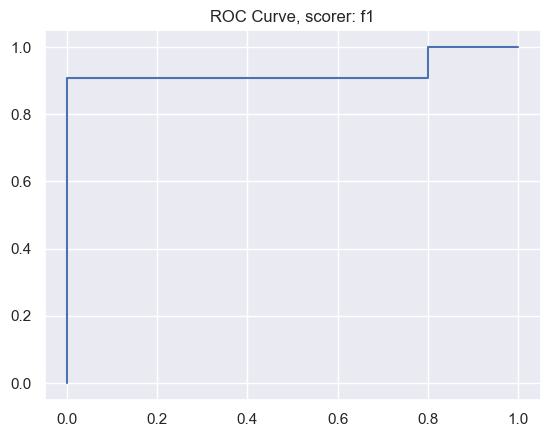

Scorer: f1
Accuracy: 0.8095238095238095
F1-score: 0.8333333333333334
ROC AUC: 0.9272727272727272
              precision    recall  f1-score   support

         0.0       0.88      0.70      0.78        10
         1.0       0.77      0.91      0.83        11

    accuracy                           0.81        21
   macro avg       0.82      0.80      0.81        21
weighted avg       0.82      0.81      0.81        21



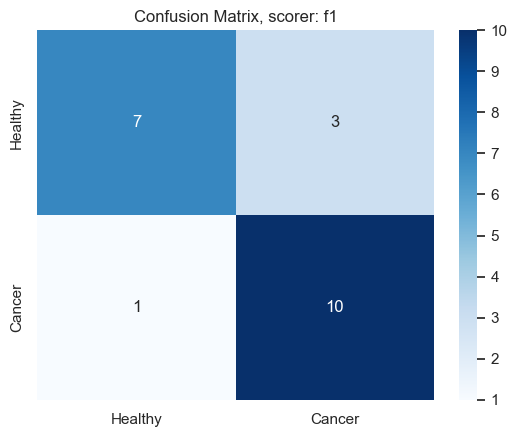

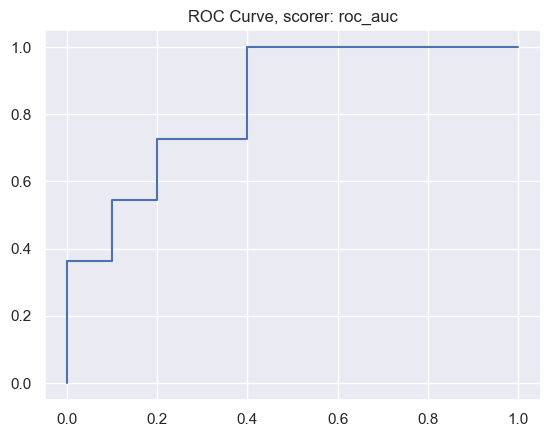

Scorer: roc_auc
Accuracy: 0.6666666666666666
F1-score: 0.6956521739130435
ROC AUC: 0.8363636363636364
              precision    recall  f1-score   support

         0.0       0.67      0.60      0.63        10
         1.0       0.67      0.73      0.70        11

    accuracy                           0.67        21
   macro avg       0.67      0.66      0.66        21
weighted avg       0.67      0.67      0.67        21



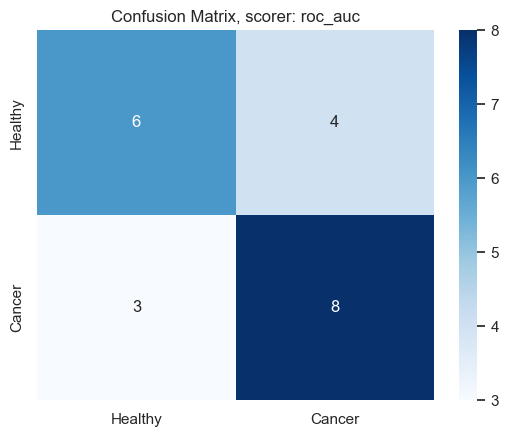

In [9]:
scorers = ['accuracy', 'f1', 'roc_auc']
for scorer in scorers:
    selector = SequentialFeatureSelector(LDA, n_features_to_select=20, direction='forward', scoring=scorer)
    X_train_sfs = selector.fit_transform(X_train_ttest, y_train)
    X_test_sfs = selector.transform(X_test_ttest)
    LDA.fit(X_train_sfs, y_train)
    y_pred_lda = LDA.predict(X_test_sfs)
    fpr, tpr, thresholds = roc_curve(y_test, LDA.predict_proba(X_test_sfs)[:,1])
    roc_auc = auc(fpr, tpr)
    plt.title('ROC Curve, scorer: %s' % scorer)
    plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % roc_auc)
    plt.show()
    print("Scorer:", scorer)
    print("Accuracy:", accuracy_score(y_test, y_pred_lda))
    print("F1-score:", f1_score(y_test, y_pred_lda))
    print("ROC AUC:", roc_auc_score(y_test, LDA.predict_proba(X_test_sfs)[:,1]))
    print(classification_report(y_test, y_pred_lda))
    cm = confusion_matrix(y_test, y_pred_lda) 
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Healthy', 'Cancer'], yticklabels=['Healthy', 'Cancer'])
    plt.title('Confusion Matrix, scorer: %s' % scorer)
    plt.show()

### QDA

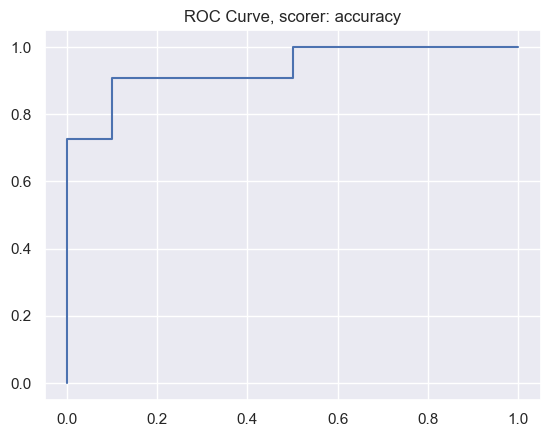

Scorer: accuracy
Accuracy: 0.8571428571428571
F1-score: 0.8695652173913043
ROC AUC: 0.9363636363636364
              precision    recall  f1-score   support

         0.0       0.89      0.80      0.84        10
         1.0       0.83      0.91      0.87        11

    accuracy                           0.86        21
   macro avg       0.86      0.85      0.86        21
weighted avg       0.86      0.86      0.86        21



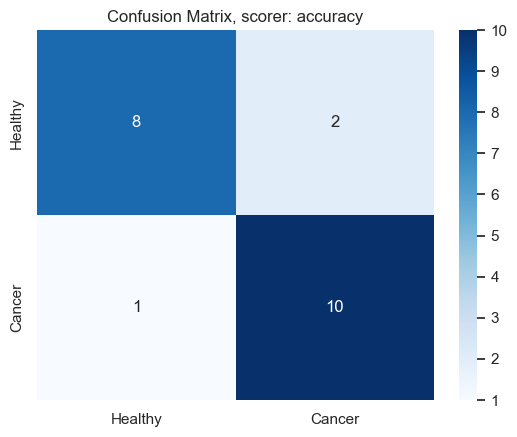

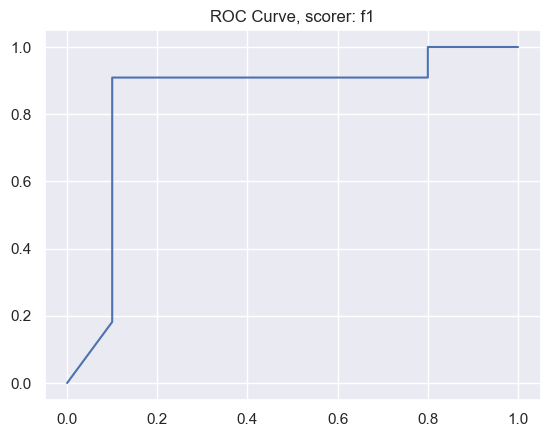

Scorer: f1
Accuracy: 0.8571428571428571
F1-score: 0.8571428571428571
ROC AUC: 0.8454545454545453
              precision    recall  f1-score   support

         0.0       0.82      0.90      0.86        10
         1.0       0.90      0.82      0.86        11

    accuracy                           0.86        21
   macro avg       0.86      0.86      0.86        21
weighted avg       0.86      0.86      0.86        21



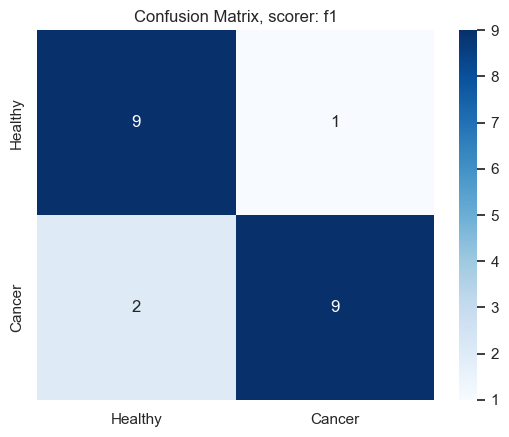

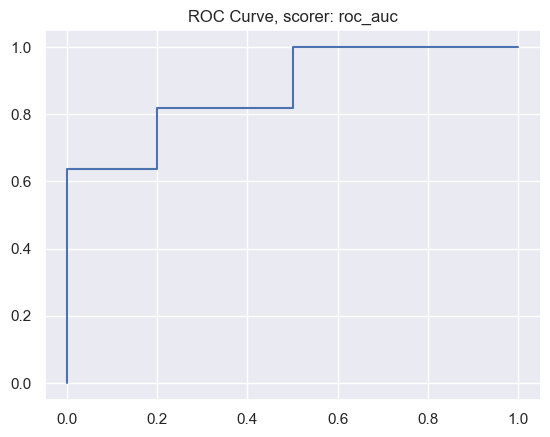

Scorer: roc_auc
Accuracy: 0.8095238095238095
F1-score: 0.8181818181818182
ROC AUC: 0.8727272727272728
              precision    recall  f1-score   support

         0.0       0.80      0.80      0.80        10
         1.0       0.82      0.82      0.82        11

    accuracy                           0.81        21
   macro avg       0.81      0.81      0.81        21
weighted avg       0.81      0.81      0.81        21



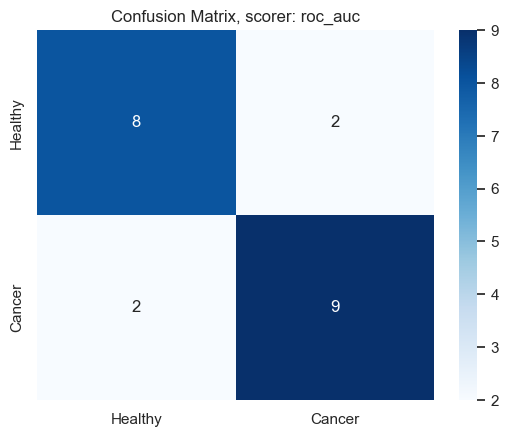

In [10]:
for scorer in scorers:
    selector = SequentialFeatureSelector(QDA, n_features_to_select=20, direction='forward', scoring=scorer)
    X_train_sfs = selector.fit_transform(X_train_ttest, y_train)
    X_test_sfs = selector.transform(X_test_ttest)
    QDA.fit(X_train_sfs, y_train)
    y_pred_qda = QDA.predict(X_test_sfs)
    fpr, tpr, thresholds = roc_curve(y_test, QDA.predict_proba(X_test_sfs)[:,1])
    roc_auc = auc(fpr, tpr)
    plt.title('ROC Curve, scorer: %s' % scorer)
    plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % roc_auc)
    plt.show()
    print("Scorer:", scorer)
    print("Accuracy:", accuracy_score(y_test, y_pred_qda))
    print("F1-score:", f1_score(y_test, y_pred_qda))
    print("ROC AUC:", roc_auc_score(y_test, QDA.predict_proba(X_test_sfs)[:,1]))
    print(classification_report(y_test, y_pred_qda))
    cm = confusion_matrix(y_test, y_pred_qda)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Healthy', 'Cancer'], yticklabels=['Healthy', 'Cancer'])
    plt.title('Confusion Matrix, scorer: %s' % scorer)
    plt.show()

### kNN

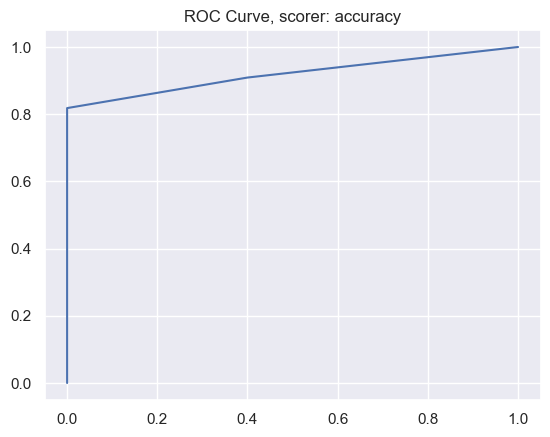

Scorer: accuracy
Accuracy: 0.9047619047619048
F1-score: 0.9
ROC AUC: 0.9181818181818182
              precision    recall  f1-score   support

         0.0       0.83      1.00      0.91        10
         1.0       1.00      0.82      0.90        11

    accuracy                           0.90        21
   macro avg       0.92      0.91      0.90        21
weighted avg       0.92      0.90      0.90        21



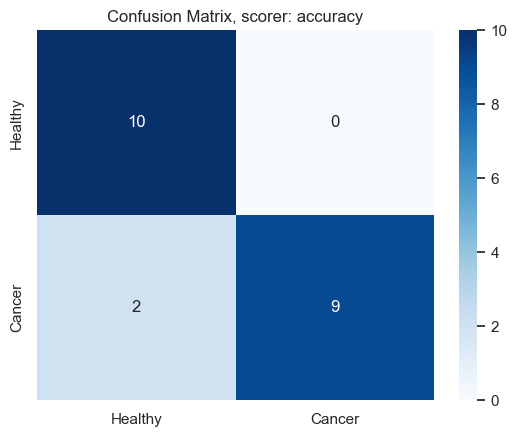

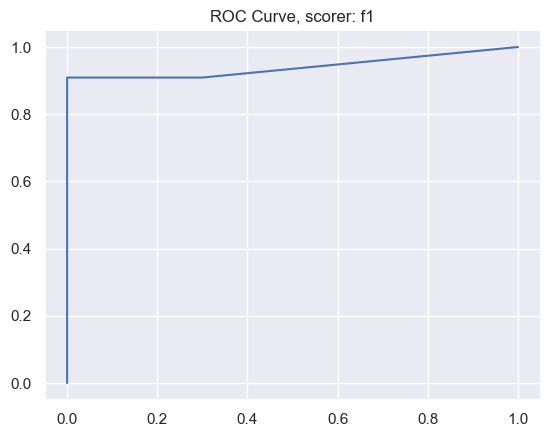

Scorer: f1
Accuracy: 0.9523809523809523
F1-score: 0.9523809523809523
ROC AUC: 0.9409090909090909
              precision    recall  f1-score   support

         0.0       0.91      1.00      0.95        10
         1.0       1.00      0.91      0.95        11

    accuracy                           0.95        21
   macro avg       0.95      0.95      0.95        21
weighted avg       0.96      0.95      0.95        21



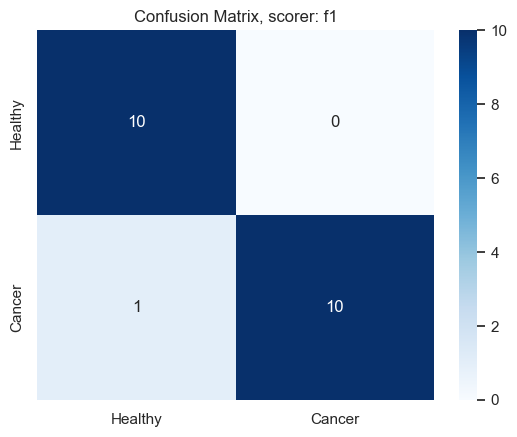

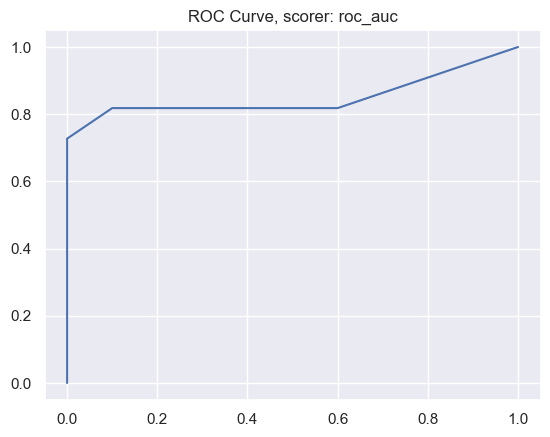

Scorer: roc_auc
Accuracy: 0.8571428571428571
F1-score: 0.8421052631578947
ROC AUC: 0.8500000000000001
              precision    recall  f1-score   support

         0.0       0.77      1.00      0.87        10
         1.0       1.00      0.73      0.84        11

    accuracy                           0.86        21
   macro avg       0.88      0.86      0.86        21
weighted avg       0.89      0.86      0.86        21



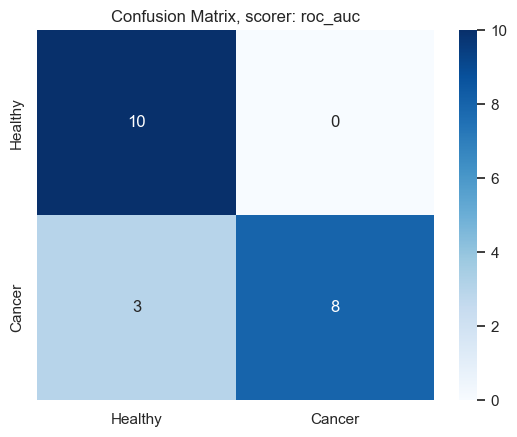

In [26]:
for scorer in scorers:
    selector = SequentialFeatureSelector(kNN, n_features_to_select=20, direction='forward', scoring=scorer)
    X_train_sfs = selector.fit_transform(X_train_ttest, y_train)
    X_test_sfs = selector.transform(X_test_ttest)
    kNN.fit(X_train_sfs, y_train)
    y_pred_knn = kNN.predict(X_test_sfs)
    fpr, tpr, thresholds = roc_curve(y_test, kNN.predict_proba(X_test_sfs)[:,1])
    roc_auc = auc(fpr, tpr)
    plt.title('ROC Curve, scorer: %s' % scorer)
    plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % roc_auc)
    plt.show()
    print("Scorer:", scorer)
    print("Accuracy:", accuracy_score(y_test, y_pred_knn))
    print("F1-score:", f1_score(y_test, y_pred_knn))
    print("ROC AUC:", roc_auc_score(y_test, kNN.predict_proba(X_test_sfs)[:,1]))
    print(classification_report(y_test, y_pred_knn))
    cm = confusion_matrix(y_test, y_pred_knn) 
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Healthy', 'Cancer'], yticklabels=['Healthy', 'Cancer'])
    plt.title('Confusion Matrix, scorer: %s' % scorer)
    plt.show()

### Logistic Regression

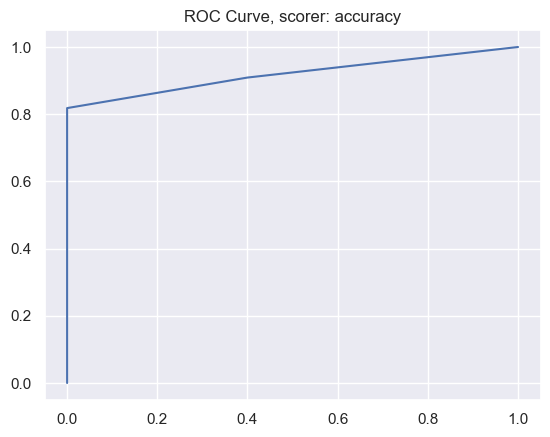

Scorer: accuracy
Accuracy: 0.9047619047619048
F1-score: 0.9
ROC AUC: 0.9181818181818182
              precision    recall  f1-score   support

         0.0       0.83      1.00      0.91        10
         1.0       1.00      0.82      0.90        11

    accuracy                           0.90        21
   macro avg       0.92      0.91      0.90        21
weighted avg       0.92      0.90      0.90        21



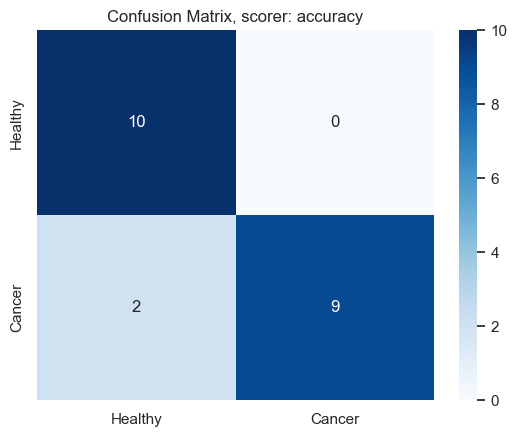

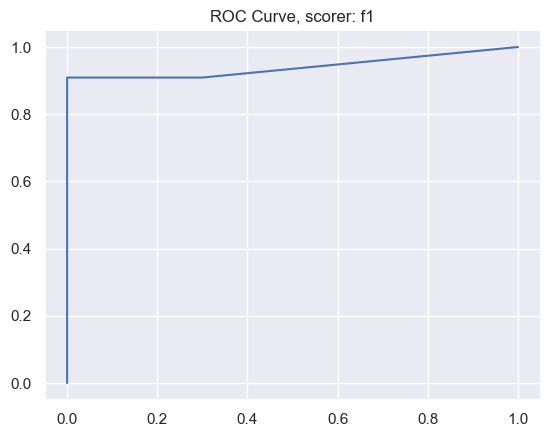

Scorer: f1
Accuracy: 0.9523809523809523
F1-score: 0.9523809523809523
ROC AUC: 0.9409090909090909
              precision    recall  f1-score   support

         0.0       0.91      1.00      0.95        10
         1.0       1.00      0.91      0.95        11

    accuracy                           0.95        21
   macro avg       0.95      0.95      0.95        21
weighted avg       0.96      0.95      0.95        21



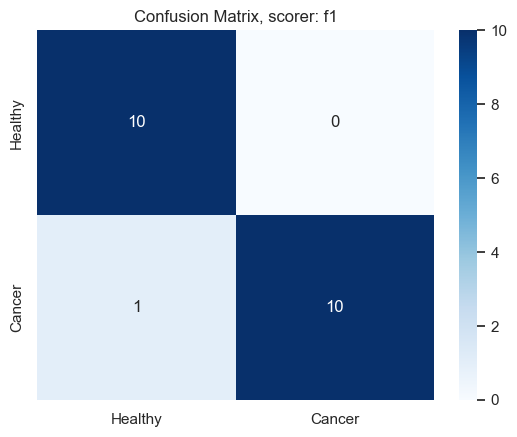

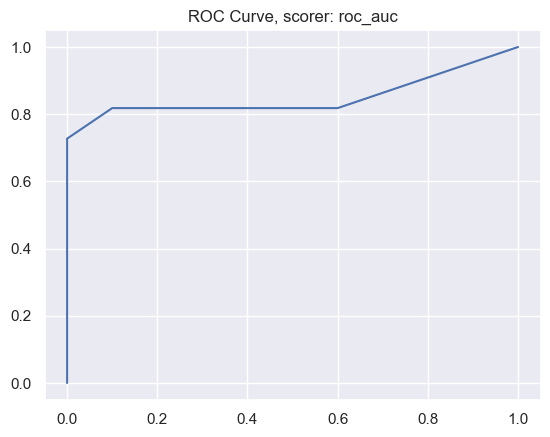

Scorer: roc_auc
Accuracy: 0.8571428571428571
F1-score: 0.8421052631578947
ROC AUC: 0.8500000000000001
              precision    recall  f1-score   support

         0.0       0.77      1.00      0.87        10
         1.0       1.00      0.73      0.84        11

    accuracy                           0.86        21
   macro avg       0.88      0.86      0.86        21
weighted avg       0.89      0.86      0.86        21



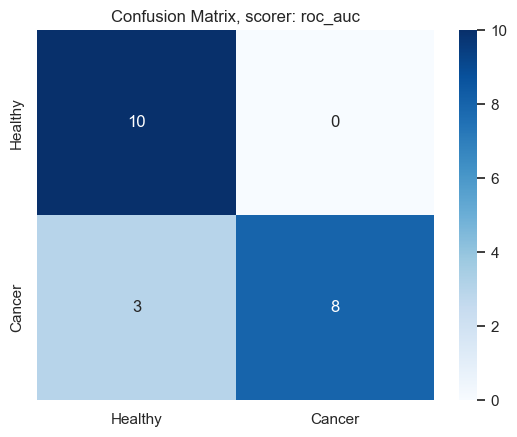

In [27]:
for scorer in scorers:
    selector = SequentialFeatureSelector(kNN, n_features_to_select=20, direction='forward', scoring=scorer)
    X_train_sfs = selector.fit_transform(X_train_ttest, y_train)
    X_test_sfs = selector.transform(X_test_ttest)
    kNN.fit(X_train_sfs, y_train)
    y_pred_knn = kNN.predict(X_test_sfs)
    fpr, tpr, thresholds = roc_curve(y_test, kNN.predict_proba(X_test_sfs)[:,1])
    roc_auc = auc(fpr, tpr)
    plt.title('ROC Curve, scorer: %s' % scorer)
    plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % roc_auc)
    plt.show()
    print("Scorer:", scorer)
    print("Accuracy:", accuracy_score(y_test, y_pred_knn))
    print("F1-score:", f1_score(y_test, y_pred_knn))
    print("ROC AUC:", roc_auc_score(y_test, kNN.predict_proba(X_test_sfs)[:,1]))
    print(classification_report(y_test, y_pred_knn))
    cm = confusion_matrix(y_test, y_pred_knn) 
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Healthy', 'Cancer'], yticklabels=['Healthy', 'Cancer'])
    plt.title('Confusion Matrix, scorer: %s' % scorer)
    plt.show()

### SVM

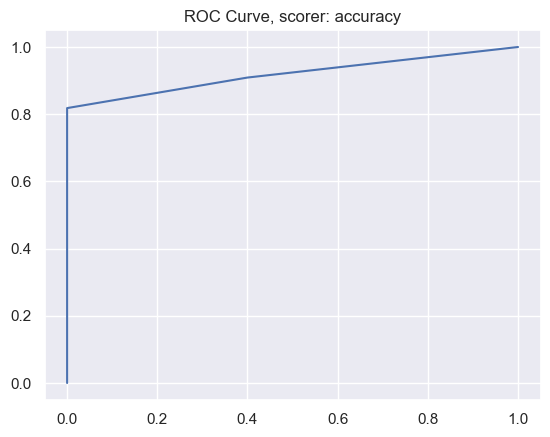

Scorer: accuracy
Accuracy: 0.9047619047619048
F1-score: 0.9
ROC AUC: 0.9181818181818182
              precision    recall  f1-score   support

         0.0       0.83      1.00      0.91        10
         1.0       1.00      0.82      0.90        11

    accuracy                           0.90        21
   macro avg       0.92      0.91      0.90        21
weighted avg       0.92      0.90      0.90        21



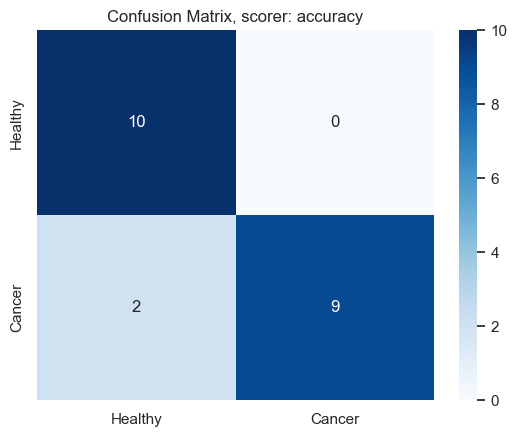

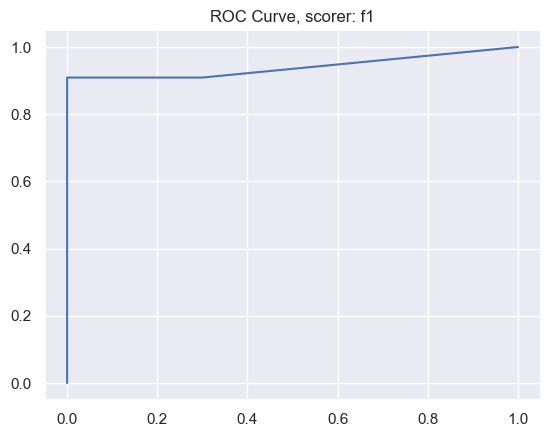

Scorer: f1
Accuracy: 0.9523809523809523
F1-score: 0.9523809523809523
ROC AUC: 0.9409090909090909
              precision    recall  f1-score   support

         0.0       0.91      1.00      0.95        10
         1.0       1.00      0.91      0.95        11

    accuracy                           0.95        21
   macro avg       0.95      0.95      0.95        21
weighted avg       0.96      0.95      0.95        21



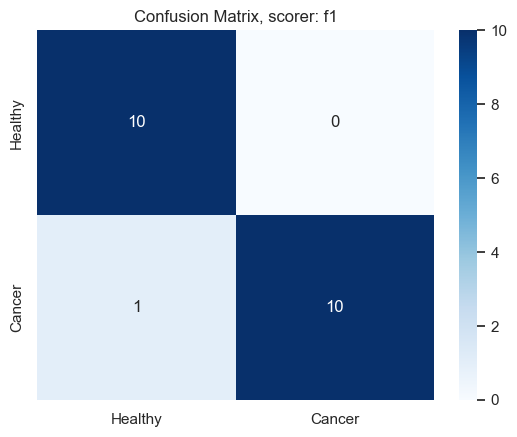

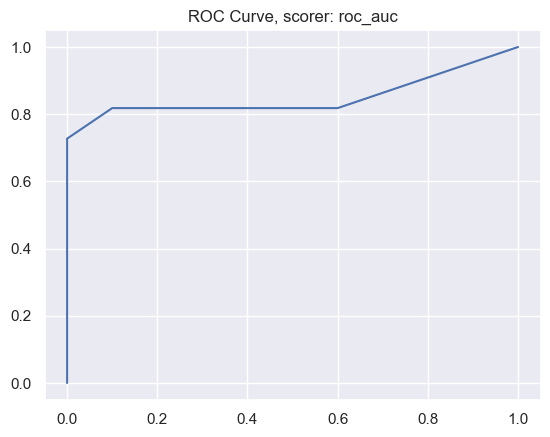

Scorer: roc_auc
Accuracy: 0.8571428571428571
F1-score: 0.8421052631578947
ROC AUC: 0.8500000000000001
              precision    recall  f1-score   support

         0.0       0.77      1.00      0.87        10
         1.0       1.00      0.73      0.84        11

    accuracy                           0.86        21
   macro avg       0.88      0.86      0.86        21
weighted avg       0.89      0.86      0.86        21



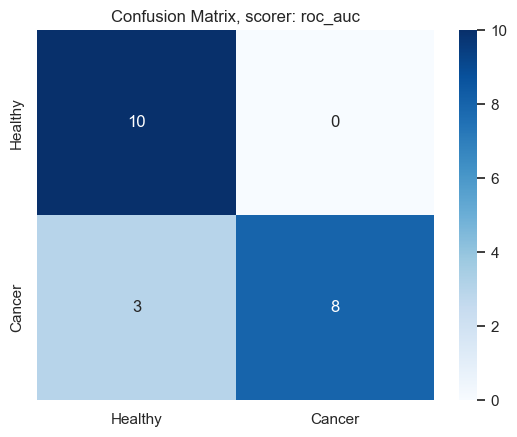

In [28]:
for scorer in scorers:
    selector = SequentialFeatureSelector(kNN, n_features_to_select=20, direction='forward', scoring=scorer)
    X_train_sfs = selector.fit_transform(X_train_ttest, y_train)
    X_test_sfs = selector.transform(X_test_ttest)
    kNN.fit(X_train_sfs, y_train)
    y_pred_knn = kNN.predict(X_test_sfs)
    fpr, tpr, thresholds = roc_curve(y_test, kNN.predict_proba(X_test_sfs)[:,1])
    roc_auc = auc(fpr, tpr)
    plt.title('ROC Curve, scorer: %s' % scorer)
    plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % roc_auc)
    plt.show()
    print("Scorer:", scorer)
    print("Accuracy:", accuracy_score(y_test, y_pred_knn))
    print("F1-score:", f1_score(y_test, y_pred_knn))
    print("ROC AUC:", roc_auc_score(y_test, kNN.predict_proba(X_test_sfs)[:,1]))
    print(classification_report(y_test, y_pred_knn))
    cm = confusion_matrix(y_test, y_pred_knn) 
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Healthy', 'Cancer'], yticklabels=['Healthy', 'Cancer'])
    plt.title('Confusion Matrix, scorer: %s' % scorer)
    plt.show()

## Wilcoxon

In [32]:
X_train, X_test, y_train, y_test = train_test_split(xs, ys, test_size=0.2, stratify=ys)

X_train_c = X_train[y_train.astype(bool)]
X_train_nc = X_train[~y_train.astype(bool)]

p_values = [mannwhitneyu(X_train_nc[col], X_train_c[col], alternative='two-sided').pvalue for col in xs.columns]
reject, pvals_corrected, _, _ = multipletests(p_values, method='bonferroni')
selected_genes = xs.columns[pd.Series(pvals_corrected) < 0.05]
X_train_wilcoxon = X_train[selected_genes]
X_test_wilcoxon = X_test[selected_genes]

### LDA

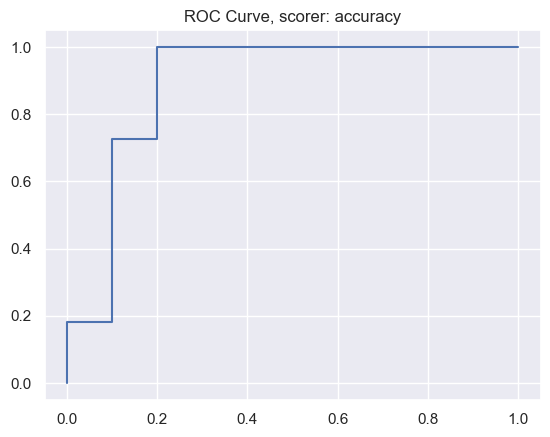

Scorer: accuracy
Accuracy: 0.9047619047619048
F1-score: 0.9166666666666666
ROC AUC: 0.890909090909091
              precision    recall  f1-score   support

         0.0       1.00      0.80      0.89        10
         1.0       0.85      1.00      0.92        11

    accuracy                           0.90        21
   macro avg       0.92      0.90      0.90        21
weighted avg       0.92      0.90      0.90        21



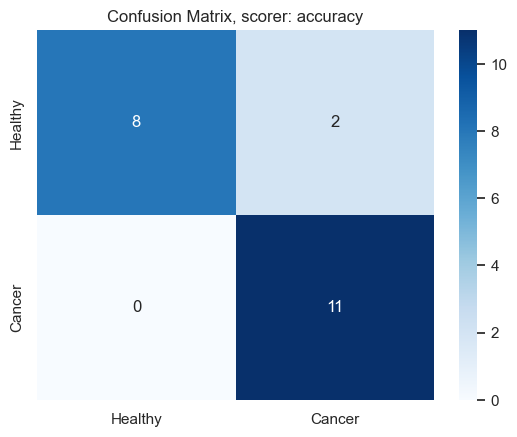

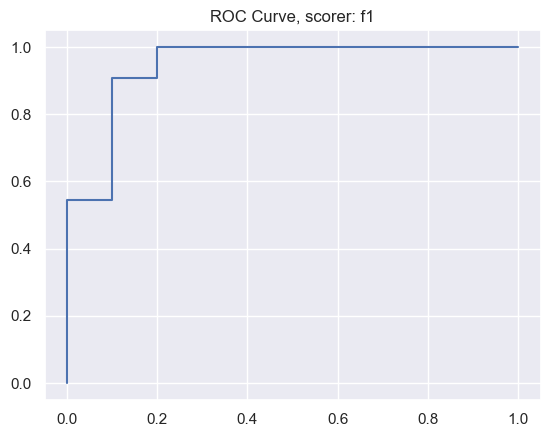

Scorer: f1
Accuracy: 0.9047619047619048
F1-score: 0.9166666666666666
ROC AUC: 0.9454545454545455
              precision    recall  f1-score   support

         0.0       1.00      0.80      0.89        10
         1.0       0.85      1.00      0.92        11

    accuracy                           0.90        21
   macro avg       0.92      0.90      0.90        21
weighted avg       0.92      0.90      0.90        21



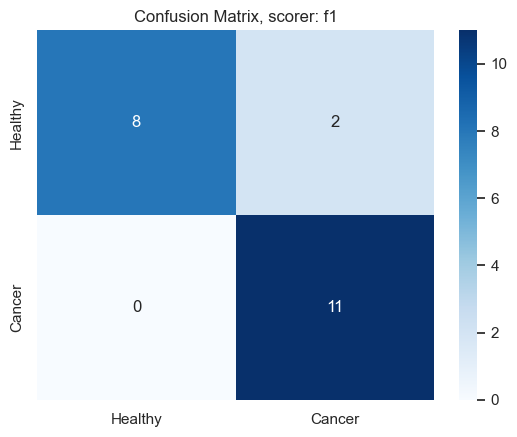

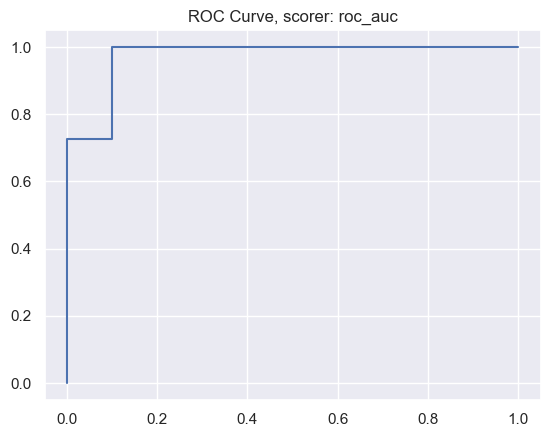

Scorer: roc_auc
Accuracy: 0.9523809523809523
F1-score: 0.9565217391304348
ROC AUC: 0.9727272727272728
              precision    recall  f1-score   support

         0.0       1.00      0.90      0.95        10
         1.0       0.92      1.00      0.96        11

    accuracy                           0.95        21
   macro avg       0.96      0.95      0.95        21
weighted avg       0.96      0.95      0.95        21



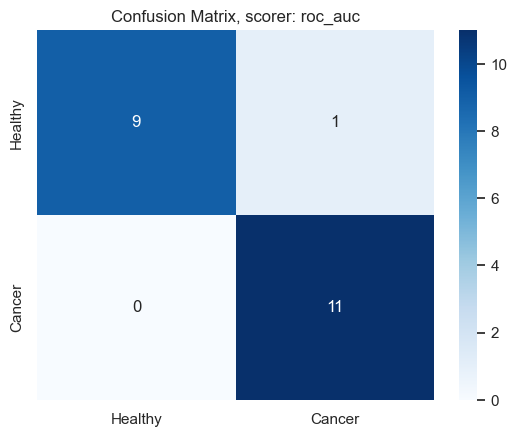

In [33]:
scorers = ['accuracy', 'f1', 'roc_auc']
for scorer in scorers:
    selector = SequentialFeatureSelector(LDA, n_features_to_select=20, direction='forward', scoring=scorer)
    X_train_sfs = selector.fit_transform(X_train_wilcoxon, y_train)
    X_test_sfs = selector.transform(X_test_wilcoxon)
    LDA.fit(X_train_sfs, y_train)
    y_pred_lda = LDA.predict(X_test_sfs)
    fpr, tpr, thresholds = roc_curve(y_test, LDA.predict_proba(X_test_sfs)[:,1])
    roc_auc = auc(fpr, tpr)
    plt.title('ROC Curve, scorer: %s' % scorer)
    plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % roc_auc)
    plt.show()
    print("Scorer:", scorer)
    print("Accuracy:", accuracy_score(y_test, y_pred_lda))
    print("F1-score:", f1_score(y_test, y_pred_lda))
    print("ROC AUC:", roc_auc_score(y_test, LDA.predict_proba(X_test_sfs)[:,1]))
    print(classification_report(y_test, y_pred_lda))
    cm = confusion_matrix(y_test, y_pred_lda) 
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Healthy', 'Cancer'], yticklabels=['Healthy', 'Cancer'])
    plt.title('Confusion Matrix, scorer: %s' % scorer)
    plt.show()

### QDA

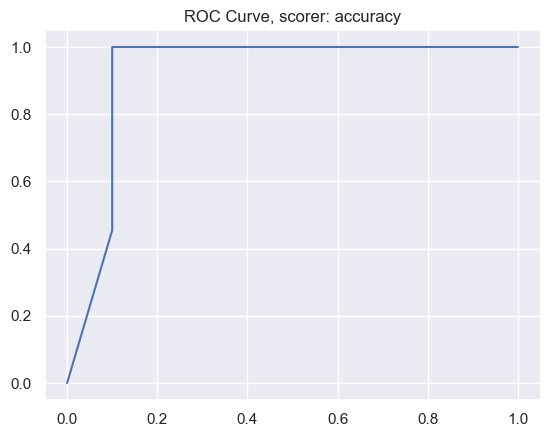

Scorer: accuracy
Accuracy: 0.9523809523809523
F1-score: 0.9565217391304348
ROC AUC: 0.9227272727272727
              precision    recall  f1-score   support

         0.0       1.00      0.90      0.95        10
         1.0       0.92      1.00      0.96        11

    accuracy                           0.95        21
   macro avg       0.96      0.95      0.95        21
weighted avg       0.96      0.95      0.95        21



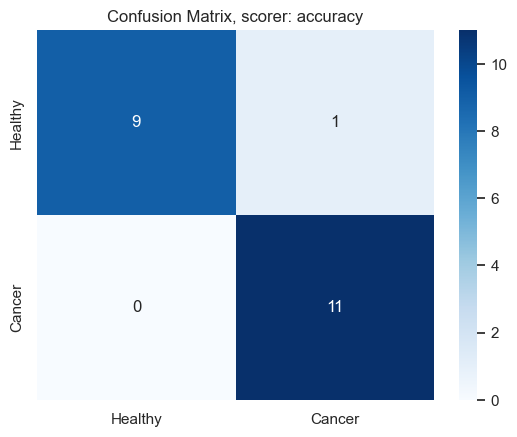

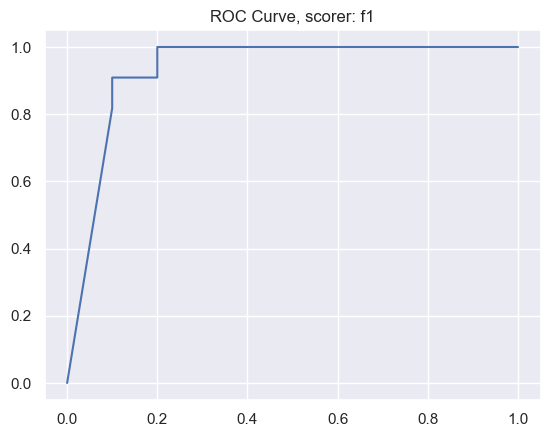

Scorer: f1
Accuracy: 0.9047619047619048
F1-score: 0.9166666666666666
ROC AUC: 0.9318181818181819
              precision    recall  f1-score   support

         0.0       1.00      0.80      0.89        10
         1.0       0.85      1.00      0.92        11

    accuracy                           0.90        21
   macro avg       0.92      0.90      0.90        21
weighted avg       0.92      0.90      0.90        21



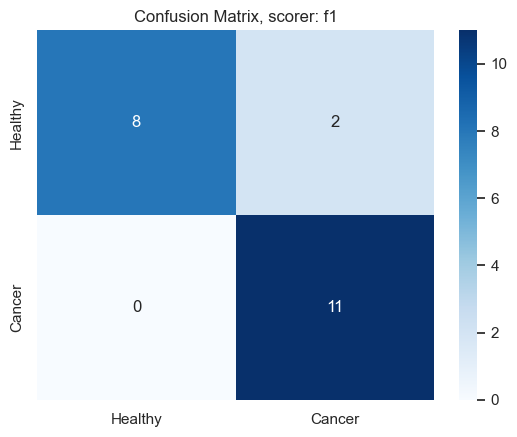

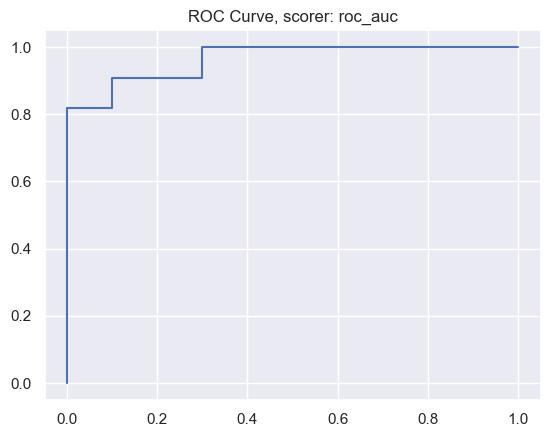

Scorer: roc_auc
Accuracy: 0.8095238095238095
F1-score: 0.8333333333333334
ROC AUC: 0.9636363636363636
              precision    recall  f1-score   support

         0.0       0.88      0.70      0.78        10
         1.0       0.77      0.91      0.83        11

    accuracy                           0.81        21
   macro avg       0.82      0.80      0.81        21
weighted avg       0.82      0.81      0.81        21



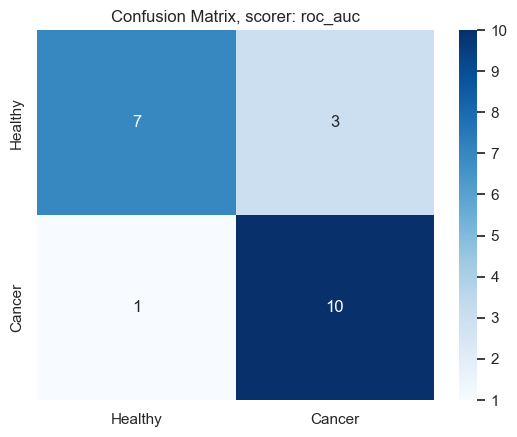

In [34]:
for scorer in scorers:
    selector = SequentialFeatureSelector(QDA, n_features_to_select=20, direction='forward', scoring=scorer)
    X_train_sfs = selector.fit_transform(X_train_wilcoxon, y_train)
    X_test_sfs = selector.transform(X_test_wilcoxon)
    QDA.fit(X_train_sfs, y_train)
    y_pred_qda = QDA.predict(X_test_sfs)
    fpr, tpr, thresholds = roc_curve(y_test, QDA.predict_proba(X_test_sfs)[:,1])
    roc_auc = auc(fpr, tpr)
    plt.title('ROC Curve, scorer: %s' % scorer)
    plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % roc_auc)
    plt.show()
    print("Scorer:", scorer)
    print("Accuracy:", accuracy_score(y_test, y_pred_qda))
    print("F1-score:", f1_score(y_test, y_pred_qda))
    print("ROC AUC:", roc_auc_score(y_test, QDA.predict_proba(X_test_sfs)[:,1]))
    print(classification_report(y_test, y_pred_qda))
    cm = confusion_matrix(y_test, y_pred_qda)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Healthy', 'Cancer'], yticklabels=['Healthy', 'Cancer'])
    plt.title('Confusion Matrix, scorer: %s' % scorer)
    plt.show()

### kNN

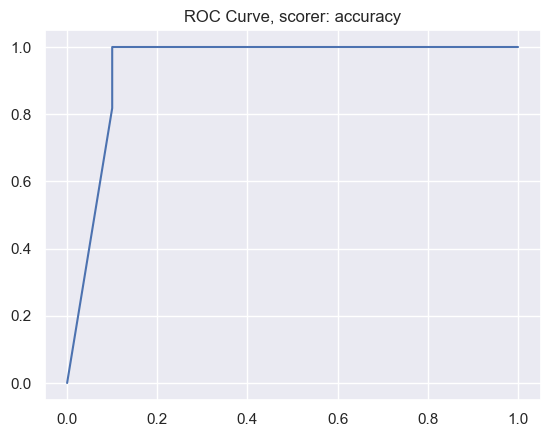

Scorer: accuracy
Accuracy: 0.9523809523809523
F1-score: 0.9565217391304348
ROC AUC: 0.9409090909090909
              precision    recall  f1-score   support

         0.0       1.00      0.90      0.95        10
         1.0       0.92      1.00      0.96        11

    accuracy                           0.95        21
   macro avg       0.96      0.95      0.95        21
weighted avg       0.96      0.95      0.95        21



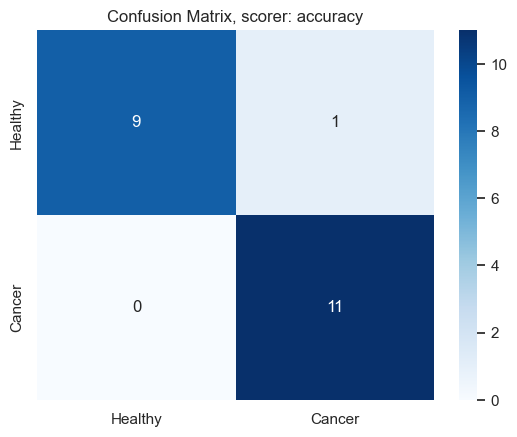

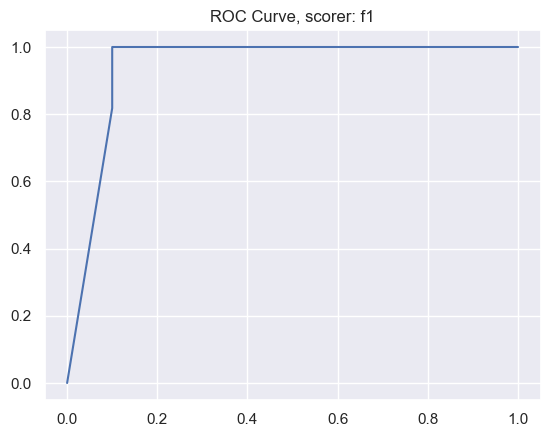

Scorer: f1
Accuracy: 0.9523809523809523
F1-score: 0.9565217391304348
ROC AUC: 0.9409090909090909
              precision    recall  f1-score   support

         0.0       1.00      0.90      0.95        10
         1.0       0.92      1.00      0.96        11

    accuracy                           0.95        21
   macro avg       0.96      0.95      0.95        21
weighted avg       0.96      0.95      0.95        21



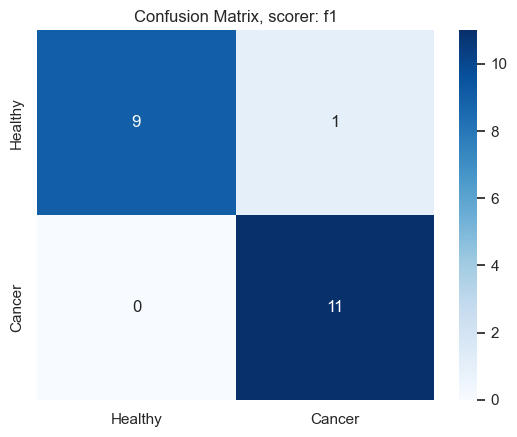

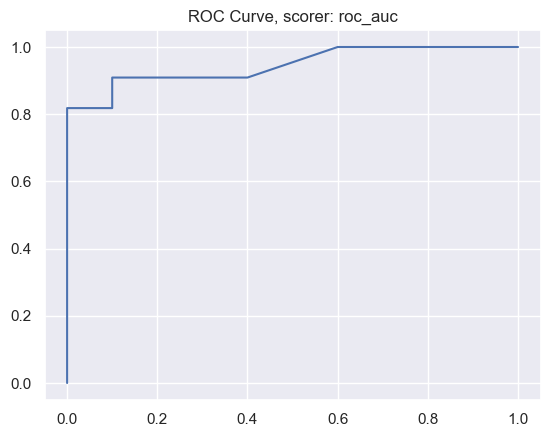

Scorer: roc_auc
Accuracy: 0.9047619047619048
F1-score: 0.9090909090909091
ROC AUC: 0.9454545454545454
              precision    recall  f1-score   support

         0.0       0.90      0.90      0.90        10
         1.0       0.91      0.91      0.91        11

    accuracy                           0.90        21
   macro avg       0.90      0.90      0.90        21
weighted avg       0.90      0.90      0.90        21



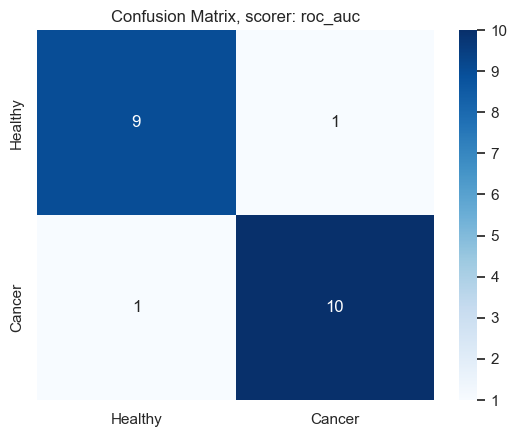

In [66]:
for scorer in scorers:
    selector = SequentialFeatureSelector(kNN, n_features_to_select=20, direction='forward', scoring=scorer)
    X_train_sfs = selector.fit_transform(X_train_wilcoxon, y_train)
    X_test_sfs = selector.transform(X_test_wilcoxon)
    kNN.fit(X_train_sfs, y_train)
    y_pred_knn = kNN.predict(X_test_sfs)
    fpr, tpr, thresholds = roc_curve(y_test, kNN.predict_proba(X_test_sfs)[:,1])
    roc_auc = auc(fpr, tpr)
    plt.title('ROC Curve, scorer: %s' % scorer)
    plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % roc_auc)
    plt.show()
    print("Scorer:", scorer)
    print("Accuracy:", accuracy_score(y_test, y_pred_knn))
    print("F1-score:", f1_score(y_test, y_pred_knn))
    print("ROC AUC:", roc_auc_score(y_test, kNN.predict_proba(X_test_sfs)[:,1]))
    print(classification_report(y_test, y_pred_knn))
    cm = confusion_matrix(y_test, y_pred_knn) 
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Healthy', 'Cancer'], yticklabels=['Healthy', 'Cancer'])
    plt.title('Confusion Matrix, scorer: %s' % scorer)
    plt.show()

### Logistic regression

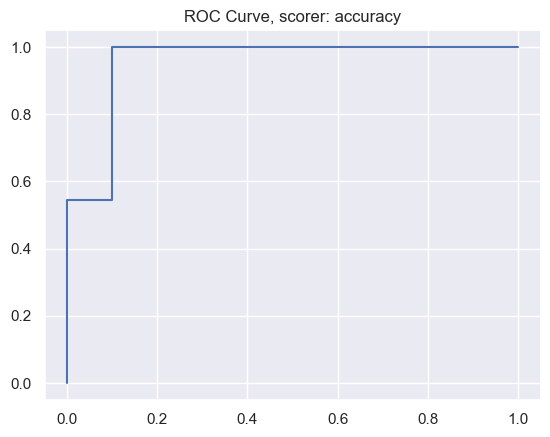

Scorer: accuracy
Accuracy: 0.9047619047619048
F1-score: 0.9166666666666666
ROC AUC: 0.9545454545454546
              precision    recall  f1-score   support

         0.0       1.00      0.80      0.89        10
         1.0       0.85      1.00      0.92        11

    accuracy                           0.90        21
   macro avg       0.92      0.90      0.90        21
weighted avg       0.92      0.90      0.90        21



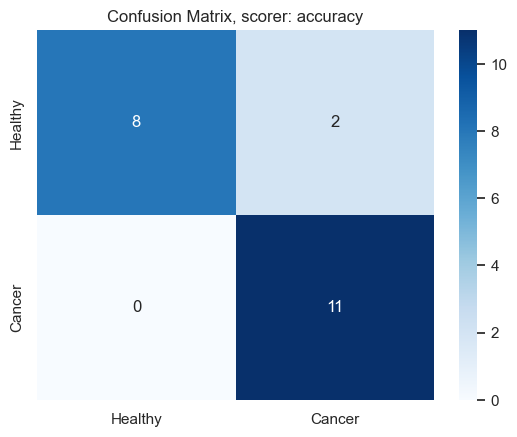

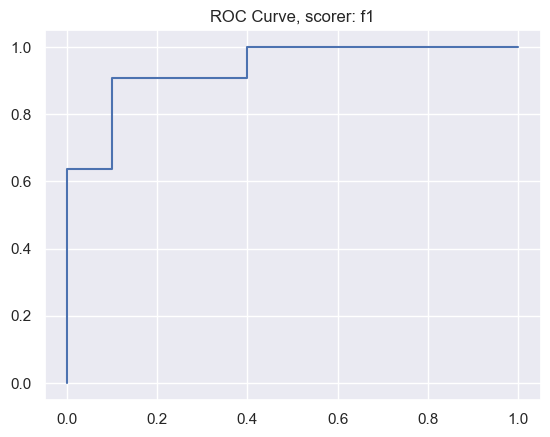

Scorer: f1
Accuracy: 0.9047619047619048
F1-score: 0.9090909090909091
ROC AUC: 0.9363636363636364
              precision    recall  f1-score   support

         0.0       0.90      0.90      0.90        10
         1.0       0.91      0.91      0.91        11

    accuracy                           0.90        21
   macro avg       0.90      0.90      0.90        21
weighted avg       0.90      0.90      0.90        21



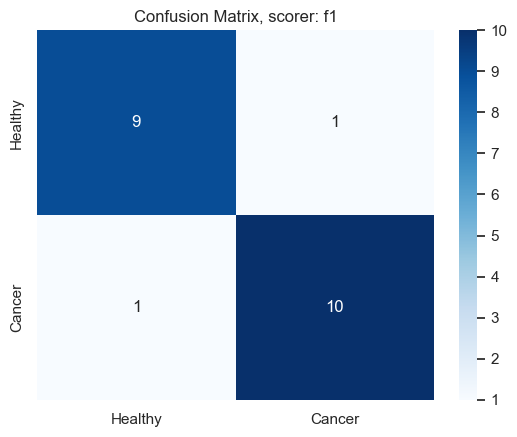

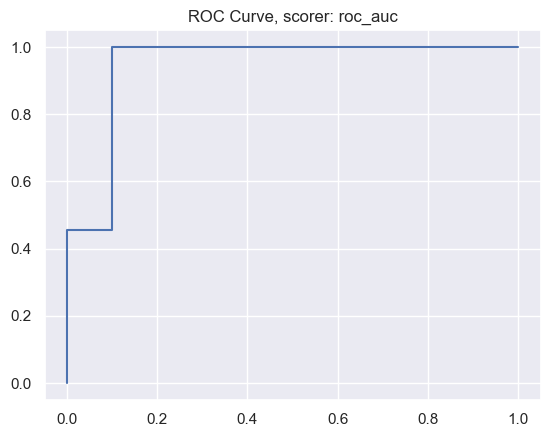

Scorer: roc_auc
Accuracy: 0.9523809523809523
F1-score: 0.9565217391304348
ROC AUC: 0.9454545454545454
              precision    recall  f1-score   support

         0.0       1.00      0.90      0.95        10
         1.0       0.92      1.00      0.96        11

    accuracy                           0.95        21
   macro avg       0.96      0.95      0.95        21
weighted avg       0.96      0.95      0.95        21



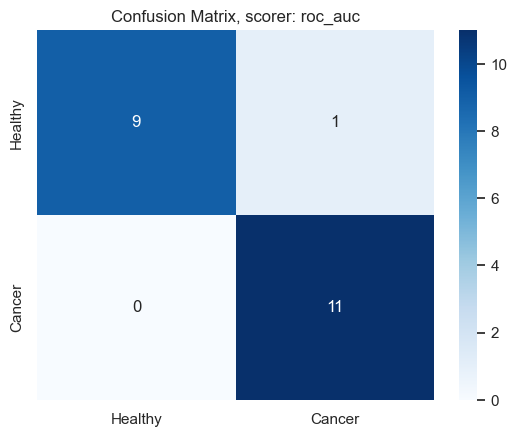

In [67]:
for scorer in scorers:
    selector = SequentialFeatureSelector(LR, n_features_to_select=20, direction='forward', scoring=scorer)
    X_train_sfs = selector.fit_transform(X_train_wilcoxon, y_train)
    X_test_sfs = selector.transform(X_test_wilcoxon)
    LR.fit(X_train_sfs, y_train)
    y_pred_lr = LR.predict(X_test_sfs)
    fpr, tpr, thresholds = roc_curve(y_test, LR.predict_proba(X_test_sfs)[:,1])
    roc_auc = auc(fpr, tpr)
    plt.title('ROC Curve, scorer: %s' % scorer)
    plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % roc_auc)
    plt.show()
    print("Scorer:", scorer)
    print("Accuracy:", accuracy_score(y_test, y_pred_lr))
    print("F1-score:", f1_score(y_test, y_pred_lr))
    print("ROC AUC:", roc_auc_score(y_test, LR.predict_proba(X_test_sfs)[:,1]))
    print(classification_report(y_test, y_pred_lr))
    cm = confusion_matrix(y_test, y_pred_lr)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Healthy', 'Cancer'], yticklabels=['Healthy', 'Cancer'])
    plt.title('Confusion Matrix, scorer: %s' % scorer)
    plt.show()

### SVM

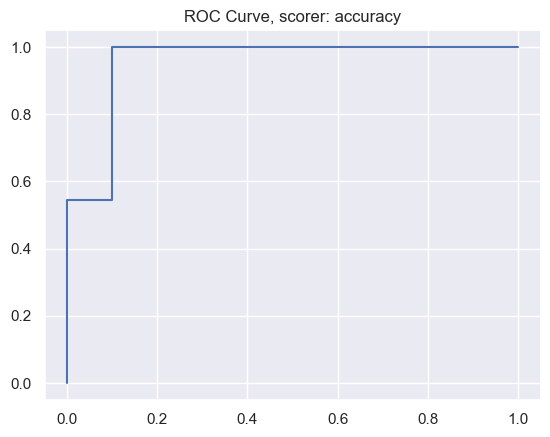

Scorer: accuracy
Accuracy: 0.9047619047619048
F1-score: 0.9090909090909091
ROC AUC: 0.9545454545454546
              precision    recall  f1-score   support

         0.0       0.90      0.90      0.90        10
         1.0       0.91      0.91      0.91        11

    accuracy                           0.90        21
   macro avg       0.90      0.90      0.90        21
weighted avg       0.90      0.90      0.90        21



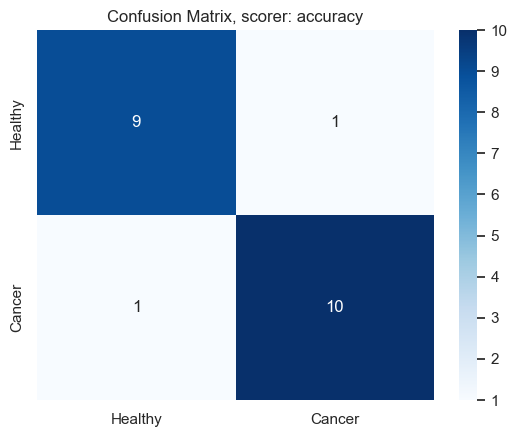

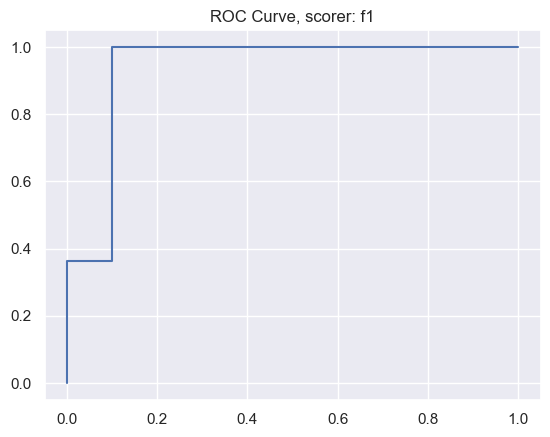

Scorer: f1
Accuracy: 0.9523809523809523
F1-score: 0.9565217391304348
ROC AUC: 0.9363636363636364
              precision    recall  f1-score   support

         0.0       1.00      0.90      0.95        10
         1.0       0.92      1.00      0.96        11

    accuracy                           0.95        21
   macro avg       0.96      0.95      0.95        21
weighted avg       0.96      0.95      0.95        21



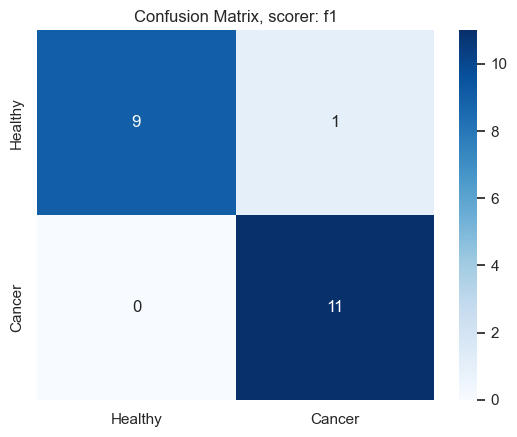

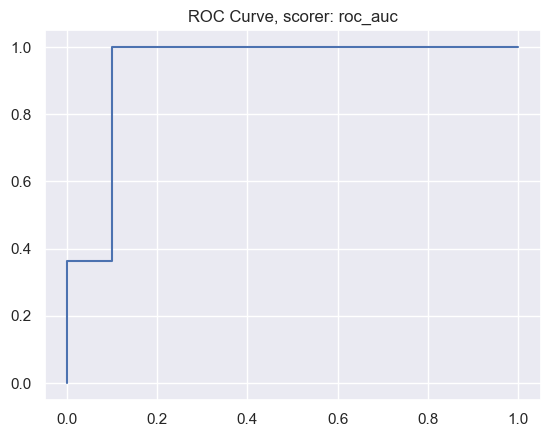

Scorer: roc_auc
Accuracy: 0.9047619047619048
F1-score: 0.9090909090909091
ROC AUC: 0.9363636363636364
              precision    recall  f1-score   support

         0.0       0.90      0.90      0.90        10
         1.0       0.91      0.91      0.91        11

    accuracy                           0.90        21
   macro avg       0.90      0.90      0.90        21
weighted avg       0.90      0.90      0.90        21



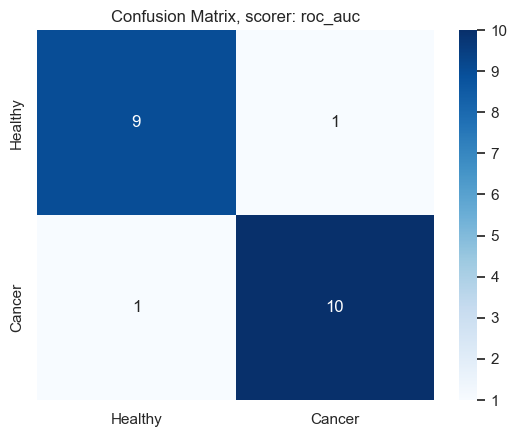

In [68]:
for scorer in scorers:
    selector = SequentialFeatureSelector(SVM, n_features_to_select=20, direction='forward', scoring=scorer)
    X_train_sfs = selector.fit_transform(X_train_wilcoxon, y_train)
    X_test_sfs = selector.transform(X_test_wilcoxon)
    SVM.fit(X_train_sfs, y_train)
    y_pred_svm = SVM.predict(X_test_sfs)
    fpr, tpr, thresholds = roc_curve(y_test, SVM.predict_proba(X_test_sfs)[:,1])
    roc_auc = auc(fpr, tpr)
    plt.title('ROC Curve, scorer: %s' % scorer)
    plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % roc_auc)
    plt.show()
    print("Scorer:", scorer)
    print("Accuracy:", accuracy_score(y_test, y_pred_svm))
    print("F1-score:", f1_score(y_test, y_pred_svm))
    print("ROC AUC:", roc_auc_score(y_test, SVM.predict_proba(X_test_sfs)[:,1]))
    print(classification_report(y_test, y_pred_svm))
    cm = confusion_matrix(y_test, y_pred_svm)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Healthy', 'Cancer'], yticklabels=['Healthy', 'Cancer'])
    plt.title('Confusion Matrix, scorer: %s' % scorer)
    plt.show()